In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

from pathlib import Path
from datetime import timedelta

import os
import time
import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

import tensorflow as tf

# Configuraciones
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
sns.color_palette("colorblind")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
tf.__version__

'2.20.0'

In [4]:
def clean_timestamp_column(df, col='Timestamp'):
    
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y %I:%M:%S %p', errors='coerce')
    df = df.dropna(subset=[col])
    df = df[df[col].dt.year != 1970]
    
    return df.reset_index(drop=True)

In [5]:
def load_swat_dataset(base_path: str) -> pd.DataFrame:
    all_dfs = []
    block_id = 1

    for folder in sorted(os.listdir(base_path)):
        folder_path = os.path.join(base_path, folder)
        
        if not os.path.isdir(folder_path):
            continue
        
        folder_dfs = []
        for file in os.listdir(folder_path):
            if file.endswith('.csv'):
                file_path = os.path.join(folder_path, file)
                try:
                    df = pd.read_csv(file_path)
                    
                    if 'Timestamp' in df.columns:
                        df = clean_timestamp_column(df)
                    
                    folder_dfs.append(df)
                except Exception as e:
                    print(f"Error al leer {file_path}: {e}")
        
        if folder_dfs:
            folder_df = pd.concat(folder_dfs, ignore_index=True)
            folder_df['Block_ID'] = block_id
            all_dfs.append(folder_df)
            print(f"Bloque {block_id}: {folder} - {len(folder_df)} registros")
            block_id += 1

    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    print(f"\nDataset combinado: {combined_df.shape[0]} filas, {combined_df.shape[1]} columnas")
    print(f"Total bloques: {combined_df['Block_ID'].nunique()}")
    
    return combined_df

In [ ]:
df_2021 = load_swat_dataset('data_raw/2021')

Bloque 1: _20210622 - 2200 registros
Bloque 2: _20210623 - 15199 registros
Bloque 3: _20210624 - 14128 registros
Bloque 4: _20210625 - 16417 registros
Bloque 5: _20210628 - 10767 registros
Bloque 6: _20210629 - 13939 registros
Bloque 7: _20210702 - 12342 registros
Bloque 8: _20210712 - 12299 registros
Bloque 9: _20210714 - 6652 registros
Bloque 10: _20210721 - 13036 registros

Dataset combinado: 116979 filas, 97 columnas
Total bloques: 10


In [7]:
df_2021.columns

Index(['Timestamp', 'Annotation', 'Other Anomalies', 'A#AEGIS', 'A#AICrit',
       'A#Attester', 'A#DAD', 'A#HybMon', 'A#Stef-Phy', 'A#Superdetector',
       'FIT101', 'LIT101', 'MV101', 'P102', 'P101', 'AIT202', 'AIT203',
       'AIT201', 'FIT201', 'MV201', 'P208', 'P207', 'P206', 'P204', 'P205',
       'P203', 'P202', 'P201', 'AIT301', 'AIT302', 'AIT303', 'DPIT301',
       'FIT301', 'LIT301', 'MV301', 'MV302', 'MV304', 'MV303', 'P301', 'P302',
       'AIT402', 'AIT401', 'FIT401', 'LIT401', 'P402', 'P403', 'P404', 'P401',
       'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT503', 'FIT502',
       'FIT504', 'FIT501', 'MV504', 'MV503', 'MV501', 'MV502', 'P501', 'P502',
       'PIT501', 'PIT502', 'PIT503', 'FIT601', 'FIT602', 'LIT601', 'LIT602',
       'P601', 'P602', 'P603', 'PLC4', 'PLC1', 'PLC6', 'PLC5', 'PLC3', 'PLC2',
       'P1SA1', 'Plant', 'Attack Hash', 'Attack Name', 'Attack State',
       'Attack Target', 'Attack Type', 'Intent', 'Attack Mode',
       'Attack Outcome', 

In [8]:
df_2021.dtypes

Timestamp           datetime64[ns]
Annotation                 float64
Other Anomalies             object
A#AEGIS                     object
A#AICrit                    object
A#Attester                 float64
A#DAD                       object
A#HybMon                    object
A#Stef-Phy                 float64
A#Superdetector            float64
FIT101                     float64
LIT101                     float64
MV101                       object
P102                        object
P101                        object
AIT202                     float64
AIT203                     float64
AIT201                     float64
FIT201                     float64
MV201                       object
P208                       float64
P207                       float64
P206                        object
P204                        object
P205                        object
P203                        object
P202                        object
P201                        object
AIT301              

In [9]:
df_2021.shape

(116979, 97)

In [10]:
# df_2021.set_index('Timestamp')['AIT203'].plot()

### Proceso de limpieza

In [11]:
df_2021['MV201'].value_counts()

MV201
1.0                                                      45538
2.0                                                      35424
0.0                                                      32406
1                                                         1867
2                                                         1718
0                                                           23
{'Name': 'Bad Input', 'IsSystem': True, 'Value': 255}        3
Name: count, dtype: int64

In [12]:
cols_to_int = [ # solo son actuadores
    'PLC1','PLC2','PLC3','PLC4','PLC5','PLC6',
    'MV101','P101','P102',
    'MV201','P201','P202','P203','P204','P205','P206','P207','P208',
    'MV301','MV302','MV303','MV304','P301','P302',
    'UV401','P401','P402','P403','P404',
    'MV501','MV502','MV503','MV504','P501','P502',
    'P601','P602','P603'
]

def clean_actuator_column(series):
    def parse_value(x):
        # Si es NaN explícito
        if pd.isna(x):
            return np.nan
        
        # Si ya es numérico válido
        if isinstance(x, (int, float, np.number)):
            if np.isnan(x):
                return np.nan
            return int(x)
        
        # Si es string
        if isinstance(x, str):
            try:
                # detectar diccionario en texto
                if x.strip().startswith("{"):
                    obj = json.loads(x.replace("'", '"'))
                    if "Bad Input" in str(obj.get("Name", "")):
                        return np.nan
                return int(float(x))
            except:
                return np.nan
        
        # Si es dict real
        if isinstance(x, dict):
            if "Bad Input" in str(x.get("Name", "")):
                return np.nan
        
        return np.nan  # fallback seguro

    cleaned = series.apply(parse_value)
    return cleaned.astype("Int64")  # entero nulo seguro

In [13]:
# limpio la columna actuadores y los valores que son incorrectos los convierto NA

for col in cols_to_int:
    df_2021[col] = clean_actuator_column(df_2021[col])

In [14]:
df_2021['MV201'].value_counts()

MV201
1    47405
2    37142
0    32429
Name: count, dtype: Int64

In [15]:
df_2021['MV302'].value_counts()

MV302
2    81304
1    35140
0      529
Name: count, dtype: Int64

### Caracterizacion de anomalias y concepto de evento de anomalia

In [16]:
DETECTOR_COLS = [
    'A#AEGIS', 'A#AICrit', 'A#Attester', 'A#DAD', 
    'A#HybMon', 'A#Stef-Phy', 'A#Superdetector', 'A#AD-Check',
    'Other Anomalies'
]

def get_active_detectors(df):
    active = []
    for col in DETECTOR_COLS:
        if col in df.columns and df[col].notna().sum() > 0:
            active.append(col)
    return active

def add_anomaly_columns(df, gap_seconds=60):
    active_detectors = get_active_detectors(df)
    print('detectores activos: ', active_detectors)
    
    df['Anomaly'] = 0
    for det in active_detectors:
        df.loc[df[det].notna(), 'Anomaly'] = 1
    
    df['Detectors'] = df.apply(
        lambda row: ', '.join([det.replace('A#', '') for det in active_detectors if pd.notna(row[det])]),
        axis=1
    )
    
    df['Anomaly_Event'] = 0
    
    if df['Anomaly'].sum() > 0:
        anomaly_times = df[df['Anomaly'] == 1].index
        time_diffs = np.diff(anomaly_times)
        gap_threshold = np.timedelta64(gap_seconds, 's')
        new_event = np.concatenate([[True], time_diffs > gap_threshold])
        event_ids = np.cumsum(new_event)
        df.loc[anomaly_times, 'Anomaly_Event'] = event_ids
        
    return df

In [17]:
df_2021 = add_anomaly_columns(df_2021, gap_seconds=1)

detectores activos:  ['A#AEGIS', 'A#AICrit', 'A#DAD', 'A#HybMon', 'Other Anomalies']


In [18]:
# anomalias y tamaño de eventos de anomalia.
df_2021[df_2021.Anomaly_Event!=0]['Anomaly_Event'].value_counts()

Anomaly_Event
740    3045
1      2182
742    1853
741    1746
427     904
       ... 
774       1
775       1
776       1
777       1
792       1
Name: count, Length: 1271, dtype: int64

In [19]:
df_2021[df_2021.Anomaly_Event==740] # ejemplo de eventos de anomalias pequeña

,Timestamp,Annotation,Other Anomalies,A#AEGIS,A#AICrit,A#Attester,A#DAD,A#HybMon,A#Stef-Phy,A#Superdetector,FIT101,LIT101,MV101,P102,P101,AIT202,AIT203,AIT201,FIT201,MV201,P208,P207,P206,P204,P205,P203,P202,P201,AIT301,AIT302,AIT303,DPIT301,FIT301,LIT301,MV301,MV302,MV304,MV303,P301,P302,AIT402,AIT401,FIT401,LIT401,P402,P403,P404,P401,UV401,AIT501,AIT502,AIT503,AIT504,FIT503,FIT502,FIT504,FIT501,MV504,MV503,MV501,MV502,P501,P502,PIT501,PIT502,PIT503,FIT601,FIT602,LIT601,LIT602,P601,P602,P603,PLC4,PLC1,PLC6,PLC5,PLC3,PLC2,P1SA1,Plant,Attack Hash,Attack Name,Attack State,Attack Target,Attack Type,Intent,Attack Mode,Attack Outcome,Target Selection,Entry Point,ASD,Attacker,Attack Id,Attack Subid,Block_ID,A#AD-Check,Anomaly,Detectors,Anomaly_Event
97291,2021-07-14 12:16:39,NaN,NaN,"UV_401_SInvariant_(1)#{'UV_401': [1, 'N.I.P'],...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,709.375854,1,1,0,6.866060,401.307343,35.824146,0.000000,0,<NA>,<NA>,1,1,1,1,1,1,6.629394,441.795258,22.440617,0.041616,0.000256,1012.080260,1,1,1,1,1,1,0.0,0.0,1.141302,804.83210,1,1,1,2,1,6.673161,461.471400,99.685980,3.845168,0.074641,0.987319,0.053166,1.147526,1,1,2,2,2,1,229.444366,2.050428,211.708542,0.0,0.0,260.926700,607.023865,1,1,1,3,3,2,12,99,2,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,AEGIS,740
97292,2021-07-14 12:16:40,NaN,NaN,"UV_401_SInvariant_(1)#{'UV_401': [1, 'N.I.P'],...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,709.415100,1,1,0,6.866060,401.307343,35.824146,0.000000,0,<NA>,<NA>,1,1,1,1,1,1,6.629394,441.795258,21.960432,0.041616,0.000256,1012.080260,1,1,1,1,1,1,0.0,0.0,1.140662,804.83210,1,1,1,2,1,6.668995,461.471400,99.685980,3.845168,0.074641,0.987319,0.053166,1.147142,1,1,2,2,2,1,229.444366,2.050428,211.708542,0.0,0.0,261.311200,607.023865,1,1,1,3,3,2,12,99,2,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,AEGIS,740
97293,2021-07-14 12:16:41,NaN,NaN,"UV_401_SInvariant_(1)#{'UV_401': [1, 'N.I.P'],...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,709.650635,1,1,0,6.866060,401.640600,35.567802,0.000000,0,<NA>,<NA>,1,1,1,1,1,1,6.620654,441.795258,21.960432,0.041616,0.000256,1012.080260,1,1,1,1,1,1,0.0,0.0,1.140662,804.79364,1,1,1,2,1,6.662587,461.291962,99.685980,3.845168,0.074641,0.987319,0.051436,1.147014,1,1,2,2,2,1,229.444366,2.050428,211.708542,0.0,0.0,261.311200,607.023865,1,1,1,3,3,2,12,99,2,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,AEGIS,740
97294,2021-07-14 12:16:42,NaN,NaN,"UV_401_SInvariant_(1)#{'UV_401': [1, 'N.I.P'],...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,709.650635,1,1,0,6.866060,401.640600,35.567802,0.000000,0,<NA>,<NA>,1,1,1,1,1,1,6.620654,441.795258,21.960432,0.041616,0.000256,1012.080260,1,1,1,1,1,1,0.0,0.0,1.140662,804.79364,1,1,1,2,1,6.660985,461.291962,99.685980,3.845168,0.074641,0.980274,0.050988,1.147014,1,1,2,2,2,1,229.444366,2.050428,211.708542,0.0,0.0,262.368622,607.824900,1,1,1,3,3,2,12,99,2,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,AEGIS,740
97295,2021-07-14 12:16:43,NaN,NaN,"UV_401_SInvariant_(1)#{'UV_401': [1, 'N.I.P'],...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,709.650635,1,1,0,6.866060,401.640600,35.567802,0.000000,0,<NA>,<NA>,1,1,1,1,1,1,6.620654,441.795258,21.960432,0.041616,0.000256,1012.080260,1,1,1,1,1,1,0.0,0.0,1.140662,804.52450,1,1,1,2,1,6.660985,461.291962,99.685980,3.845168,0.074641,0.977200,0.050988,1.147014,1,1,2,2,2,1,229.444366,2.050428,211.708542,0.0,0.0,262.368622,607.824900,1,1,1,3,3,2,12,99,2,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,AEGIS,740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100331,2021-07-14 13:12:02,NaN,NaN,"UV_401_SInvariant_(1)#{'UV_401':

In [20]:
#df_2021[df_2021.Anomaly_Event==740]['A#AEGIS'].value_counts()
#df_2021[df_2021.Anomaly_Event==740]['A#HybMon'].value_counts()

In [21]:
def clean_anomaly_events(df, min_records=3):
    """
    Elimina filas de eventos de anomalía con pocos registros
    
    Args:
        df: DataFrame con columna Anomaly_Event
        min_records: mínimo de registros para mantener el evento
    
    Returns:
        DataFrame sin eventos pequeños
    """
    if 'Anomaly_Event' not in df.columns:
        print("No hay columna Anomaly_Event")
        return df
    
    initial_len = len(df)
    
    # Contar registros por evento
    event_counts = df[df['Anomaly_Event'] > 0].groupby('Anomaly_Event').size()
    
    # Identificar eventos a eliminar
    events_to_remove = event_counts[event_counts < min_records].index
    
    print(f"Total eventos: {len(event_counts)}")
    print(f"Eventos con < {min_records} registros: {len(events_to_remove)}")
    print(f"Eventos a mantener: {len(event_counts) - len(events_to_remove)}")
    
    # Eliminar filas de eventos pequeños
    mask = df['Anomaly_Event'].isin(events_to_remove)
    df = df[~mask].copy()
    
    # Renumerar eventos restantes
    remaining_events = df[df['Anomaly_Event'] > 0]['Anomaly_Event'].unique()
    event_mapping = {old_id: new_id for new_id, old_id in enumerate(sorted(remaining_events), 1)}
    df.loc[df['Anomaly_Event'] > 0, 'Anomaly_Event'] = df.loc[df['Anomaly_Event'] > 0, 'Anomaly_Event'].map(event_mapping)
    
    final_len = len(df)
    print(f"\nFilas eliminadas: {initial_len - final_len}")
    print(f"Filas restantes: {final_len}")
    print(f"Eventos después de limpieza: {df['Anomaly_Event'].max()}")
    
    return df

In [22]:
# Elimino los eventos muy pequeños
df_2021 = clean_anomaly_events(df_2021, min_records=3)

Total eventos: 1271
Eventos con < 3 registros: 756
Eventos a mantener: 515

Filas eliminadas: 766
Filas restantes: 116213
Eventos después de limpieza: 515


In [23]:
df_2021[df_2021.Anomaly_Event!=0]['Anomaly_Event'].value_counts()

Anomaly_Event
509    3045
1      2182
511    1853
510    1746
285     904
       ... 
142       3
143       3
512       3
405       3
406       3
Name: count, Length: 515, dtype: int64

In [24]:
# Definir features (sensores + actuadores)
cols_for_clean = [
    'FIT101', 'LIT101', 'MV101', 'P101', 'P102',
    'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 
    'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'P207', 'P208',
    'AIT301', 'AIT302', 'AIT303', 'DPIT301', 'FIT301', 'LIT301',
    'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
    'AIT401', 'AIT402', 'FIT401', 'LIT401', 
    'P401', 'P402', 'P403', 'P404', 'UV401',
    'AIT501', 'AIT502', 'AIT503', 'AIT504',
    'FIT501', 'FIT502', 'FIT503', 'FIT504',
    'MV501', 'MV502', 'MV503', 'MV504', 'P501', 'P502',
    'PIT501', 'PIT502', 'PIT503',
    'FIT601', 'FIT602', 'LIT601', 'LIT602', 'P601', 'P602', 'P603'
]

**limpieza de nulos**

In [25]:
df_2021[cols_for_clean].isna().sum()

FIT101          0
LIT101          0
MV101          35
P101           21
P102           30
AIT201          0
AIT202          0
AIT203          0
FIT201          0
MV201           3
P201            7
P202            7
P203            6
P204            7
P205            8
P206            9
P207       116213
P208       116213
AIT301          0
AIT302          0
AIT303          0
DPIT301         0
FIT301          0
LIT301          0
MV301           6
MV302           6
MV303           3
MV304           5
P301            4
P302            6
AIT401          0
AIT402          0
FIT401          0
LIT401          0
P401            8
P402            8
P403            5
P404            5
UV401           6
AIT501          0
AIT502          0
AIT503          0
AIT504          0
FIT501          0
FIT502          0
FIT503          0
FIT504          0
MV501           7
MV502           8
MV503           5
MV504           3
P501            6
P502            4
PIT501          0
PIT502          0
PIT503    

In [26]:
#msno.matrix(df_2021[cols_for_clean])

In [27]:
cols_for_clean.remove('P207')
cols_for_clean.remove('P208')

In [28]:
len(cols_for_clean)

61

In [29]:
df_2021 = df_2021.dropna(subset=cols_for_clean)

In [30]:
df_2021[cols_for_clean].isna().sum().sum()

np.int64(0)

In [31]:
df_2021 = df_2021.set_index('Timestamp')
df_2021 = df_2021.sort_index()

In [32]:
def plot_heatmap(df):
    sns.set_style("white")

    # Matriz de correlación
    corr = df[cols_for_clean].corr()

    # Máscara para ocultar la parte superior
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(14, 16))

    # Estilo minimalista
    sns.heatmap(
        corr,
        mask=mask,
        annot=False,
        cmap='coolwarm',
        linewidths=0.005,            # Sin líneas
        cbar_kws={
            "shrink": 0.4,       # Más pequeña
            "pad": 0.02          # Más pegada al gráfico
        },
        square=True
    )

    # Quitar bordes para un look más limpio
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.box(False)

    plt.title('Heatmap de correlaciones Pearson de sensores y actuadores', pad=5)
    plt.show()

In [33]:
# plot_heatmap(df_2021)

In [34]:
def analyze_event_durations(df):
    """
    Analiza cuánto duran los eventos de anomalía
    """
    if 'Anomaly_Event' not in df.columns:
        return
    
    event_durations = []
    
    for event_id in range(1, int(df['Anomaly_Event'].max()) + 1):
        event_data = df[df['Anomaly_Event'] == event_id]
        if len(event_data) > 0:
            duration = (event_data.index.max() - event_data.index.min()).total_seconds()
            n_records = len(event_data)
            event_durations.append({
                'Event': event_id,
                'Duration_sec': duration,
                'Records': n_records
            })
    
    df_events = pd.DataFrame(event_durations)
    
    print(f"\nEstadísticas de duración (segundos):")
    print(f"  Media: {df_events['Duration_sec'].mean():.1f}s")
    print(f"  Mediana: {df_events['Duration_sec'].median():.1f}s")
    print(f"  Desviacion: {df_events['Duration_sec'].std():.1f}s")
    print(f"  Min: {df_events['Duration_sec'].min():.1f}s")
    print(f"  Max: {df_events['Duration_sec'].max():.1f}s")
    print(f"  P25: {df_events['Duration_sec'].quantile(0.25):.1f}s")
    print(f"  P75: {df_events['Duration_sec'].quantile(0.75):.1f}s")
    
    print(f"\nEstadísticas de registros:")
    print(f"  Media: {df_events['Records'].mean():.1f}")
    print(f"  Mediana: {df_events['Records'].median():.1f}")
    
    # Distribución
    print("\nDistribución de duraciones:")
    bins = [0, 10, 30, 60, 120, 300, float('inf')]
    labels = ['<10s', '10-30s', '30-60s', '60-120s', '120-300s', '>300s']
    df_events['Duration_bin'] = pd.cut(df_events['Duration_sec'], bins=bins, labels=labels)
    print(df_events['Duration_bin'].value_counts().sort_index())
    
    return df_events

def plot_event_duration_boxplot(df_events):
    durations = df_events['Duration_sec']

    plt.figure(figsize=(6, 3))
    plt.boxplot(
        durations,
        vert=False,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor=plt.cm.coolwarm(0.3), alpha=0.8),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='gray'),
        capprops=dict(color='gray')
    )

    plt.xlabel("Duración de eventos de anomalía (segundos)")
    plt.title(f"Duración típica de anomalías")
    plt.grid(axis='x', alpha=0.15)

    plt.tight_layout()
    plt.show()

def plot_event_duration_bars(df_events):
    bins = [0, 10, 30, 60, 120, 300, float('inf')]
    labels = ['<10s', '10-30s', '30-60s', '60-120s', '120-300s', '>300s']

    df_events['Duration_bin'] = pd.cut(
        df_events['Duration_sec'],
        bins=bins,
        labels=labels
    )

    counts = df_events['Duration_bin'].value_counts().sort_index()

    plt.figure(figsize=(7, 3.5))

    bars = plt.bar(
        counts.index.astype(str),
        counts.values
    )

    # Colores coolwarm
    cmap = plt.cm.coolwarm
    for i, bar in enumerate(bars):
        bar.set_color(cmap(i / len(bars)))
        bar.set_alpha(0.85)

    # Línea vertical en 60s (frontera conceptual)
    plt.axvline(
        x=labels.index('30-60s') + 0.5,
        linestyle='--',
        linewidth=2,
        alpha=0.7
    )

    plt.xlabel("Duración del evento")
    plt.ylabel("Número de eventos de anomalía")
    plt.title("Distribución discreta de duración de eventos de anomalía")
    plt.grid(axis='y', alpha=0.15)

    plt.tight_layout()
    plt.show()



Estadísticas de duración (segundos):
  Media: 52.0s
  Mediana: 14.0s
  Desviacion: 291.9s
  Min: 0.0s
  Max: 4117.0s
  P25: 7.0s
  P75: 16.0s

Estadísticas de registros:
  Media: 42.3
  Mediana: 14.0

Distribución de duraciones:
Duration_bin
<10s        173
10-30s      308
30-60s       10
60-120s       3
120-300s      4
>300s        16
Name: count, dtype: int64


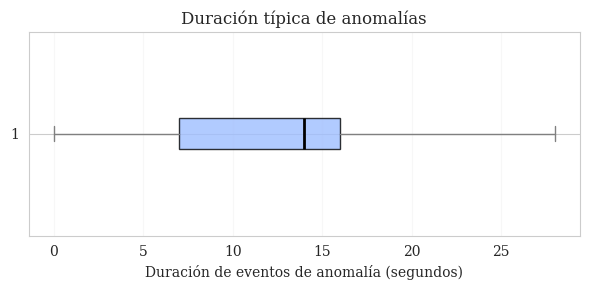

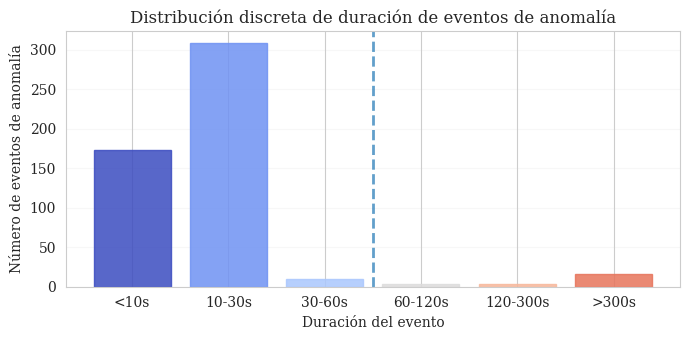

In [35]:
df_events = analyze_event_durations(df_2021)
plot_event_duration_boxplot(df_events)
plot_event_duration_bars(df_events)

In [36]:
df_2021.to_csv('df.csv')